# IMAGE - Thay đổi kích thước và chất lượng ảnh và định lượng mức độ mất mát thông tin.

# Mục lục
1. [Cơ sở lý thuyết](#sec-1)
    - [1.1. Peak Signal-to-Noise Ratio (PSNR)](#sec-1-1)
    - [1.2. Structural Similarity Index (SSIM)](#sec-1-2)
2. [Bản chất và So sánh](#sec-2)
    - [2.1. Bản chất về mặt công thức](#sec-2-1)
        - [2.1.1. PSNR](#sec-2-1-1)
        - [2.1.2. SSIM](#sec-2-1-2)
    - [2.2. So sánh](#sec-2-2)

3. [Ý nghĩa của con số trả về khi tính](#sec-3)
4. [Ablation Study: Đánh giá Tác động của Kỹ thuật Thay đổi Kích thước Ảnh](#sec-4)
    - [4.1. Tiền xử lý, trích xuất đặc trưng và tiến hành huấn luyện](#sec-4-1)
    - [4.2. Trực quan hóa Dữ liệu](#sec-4-2)
    - [4.3. Phân tích](#sec-4-3)
        - [4.3.1. Phân tích Xu hướng biến thiên của các Độ đo](#sec-4-3-1)
        - [4.3.2. Giải thích sự thay đổi](#sec-4-3-2)
        - [4.3.3. Lựa chọn Kích thước tối ưu](#sec-4-3-3)

<a id="sec-1"></a>

# 1. Cơ sở lý thuyết

<a id="sec-1-1"></a>

## 1.1. Peak Signal-to-Noise Ratio (PSNR)
- PSNR được tính dựa trên **sai số bình phương trung bình (MSE - Mean Squared Error) giữa ảnh gốc ($I$) và ảnh đã xử lý ($K$)** như sau:$$MSE = \frac{1}{m \cdot n} \sum_{i=0}^{m-1} \sum_{j=0}^{n-1} [I(i,j) - K(i,j)]^2$$
  *Trong đó:*
  - *$I(i, j)$ là giá trị của pixel tại hàng $i$, cột $j$ của ảnh gốc.*
  - *$K(i, j)$ là giá trị của pixel tại hàng $i$, cột $j$ đó nhưng ở ảnh đã qua xử lý.*
- Từ đó ta có công thức tính PSNR (đơn vị Decibel - dB) là:$$PSNR = 10 \cdot \log_{10} \left( \frac{MAX_I^2}{MSE} \right)$$
  *Trong đó: $MAX_I$ là giá trị pixel tối đa có thể có*

<a id="sec-1-2"></a>

## 1.2. Structural Similarity Index (SSIM)
- SSIM thì được tính trên **tích của 3 thành phần: Độ chói (Luminance), Độ tương phản (Contrast) và Cấu trúc (Structure)**.$$SSIM(x, y) = [l(x,y)]^\alpha \cdot [c(x,y)]^\beta \cdot [s(x,y)]^\gamma$$Với công thức rút gọn thường dùng ($\alpha=\beta=\gamma=1$):$$SSIM(x, y) = \frac{(2\mu_x\mu_y + C_1)(2\sigma_{xy} + C_2)}{(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)}$$
  *Trong đó:*
  - *$\mu_x, \mu_y$: Giá trị trung bình của vùng x và y.*
  - *$\sigma_x, \sigma_y$: Phương sai của vùng x và y.*
  - *$\sigma_{xy}$: Hiệp phương sai của vùng x và y.*

<a id="sec-2"></a>

# 2. Bản chất và So sánh

<a id="sec-2-1"></a>

## 2.1. Bản chất về mặt công thức: 

<a id="sec-2-1-1"></a>

### 2.1.1. PSNR: 
- Bản chất của PSNR thể hiện qua:
  + Chỉ số MSE cho biết **sai số bình phương trung bình giữa ảnh gốc và ảnh đã xử lý**, cụ thể thì kết quả của $[I(i,j) - K(i,j)]^2$ là **khoảng cách (sai số) trực tiếp về mặt con số giữa hai điểm ảnh trên cùng 1 vị trí**. **Vì vậy về bản chất nó thể hiện lượng thông tin bị nhiễu sau khi được xử lý**.
  + MAX_I là **giá trị tối đa của pixel** trên ảnh.
- Vậy nên, PSNR là **tỷ lệ giữa bình phương lượng tín hiệu tối đa (thể hiện qua giá trị pixel) từ ảnh gốc và lượng nhiễu có được sau khi xử lý**. PSNR thường sẽ sử dụng đơn vị Decibel (dB) để so sánh công suất của hai tín hiệu ảnh bất kỳ.

<a id="sec-2-1-2"></a>

### 2.1.2. SSIM: 
- Công thức SSIM **về bản chất dựa trên ba thông số này để so sánh: Độ chói (Luminance), Độ tương phản (Contrast) và Cấu trúc (Structure)**. Từ đó rút ra được các tính chất xoay quanh SSIM như sau:
  + SSIM được sử dụng để **đo mức độ giống nhau giữa ảnh gốc và ảnh đã xử lý**.
  + Một ảnh sau khi xử lý được đánh giá là tốt nếu:
    + Những điểm ảnh có mức độ sáng tối khác nhau, và **càng có nhiều mức độ sáng tối càng có nhiều chi tiết ảnh** => **Ảnh chất lượng tốt**
    + Một bức ảnh **không phải độ tương phản càng cao thì càng tốt** mà nên có **sự hài hòa cân đối giữa sáng và tối**. => **Độ da dạng**

<a id="sec-2-2"></a>

## 2.2. So sánh: 
- 2 chỉ số **khác nhau về bản chất nhưng thường tỉ lệ thuận**. Cụ thể:
  + PSNR tính toán dựa trên **cường độ pixel (thuần tuý về mặt vật lý)** trong khi SSIM tính toán dựa trên **cảm nhận từ việc quan sát của con người thông qua các tính chất về độ chói, sự tương phản và cấu trúc ảnh**.
  + Bên cạnh đó, dựa vào bản chất từ công thức, PSNR **đánh giá chất lượng ảnh hoàn toàn từ tính toán giá trị pixel bị mất mát (sự nhiễu)**, trong khi SSIM **đánh giá theo sự biến dạng hoặc độ mờ bức ảnh**.
  + Vậy nên, PSNR **được dùng khi cần độ chính xác dữ liệu tuyệt đối (truyền tín hiệu, nén tệp)**. Còn SSIM **sẽ được dùng khi ảnh đầu ra phục vụ cho mắt người quan sát (resize, lọc nhiễu, ...)**.

<a id="sec-3"></a>

# 3. Ý nghĩa của con số trả về khi tính 
- **Với PSNR (Đơn vị là dB)**
  + **Giá trị lớn ( > 40 dB)**: Ảnh cực kỳ chất lượng, mắt người gần như không thể phân biệt được với ảnh gốc.
  + **Giá trị trung bình (30 - 40 dB)**: Chất lượng tốt, sự khác biệt là có nhưng khó nhận ra nếu không nhìn kỹ.
  + **Giá trị thấp ( < 25 dB)**: Ảnh bị nhiễu nặng, mờ hoặc vỡ nét rõ rệt.
  + **Vô hạn ($\infty$)**: Hai ảnh hoàn toàn giống hệt nhau ($MSE = 0$).
- **Với SSIM (Khoảng giá trị từ 0 đến 1)**
  + **Bằng 1**: Hai ảnh giống hệt nhau về mặt cấu trúc.
  + **Gần bằng 1 (0.95 - 0.99)**: Ảnh giữ lại được hầu hết các chi tiết sắc nét và cấu trúc của vật thể.
  + **Trung bình (0.5 - 0.8)**: Cấu trúc ảnh bắt đầu bị biến dạng, các cạnh bị mờ đi đáng kể.
  + **Gần bằng 0**: Ảnh không còn giữ được bất kỳ mối liên hệ cấu trúc nào với bản gốc (thường là ảnh rác hoặc nhiễu trắng).

<a id="sec-4"></a>

# 4. Ablation Study: Đánh giá Tác động của Kỹ thuật Thay đổi Kích thước Ảnh

<a id="sec-4-1"></a>

## 4.1. Tiền xử lý, trích xuất đặc trưng và tiến hành huấn luyện
Pipeline được thiết kế thành các module độc lập:
1. **Module Tiền xử lý và Trích xuất đặc trưng:** Đảm nhiệm việc resize, đo lường IQA (PSNR, SSIM) và khởi tạo ma trận Numpy `X, y`.
2. **Module Máy học:** Đảm nhiệm việc Cross-Validation và đánh giá các độ đo phân loại bằng thuật toán Logistic Regression dùng Stochastic Gradient Descent (SGD).

In [1]:
import sys
import os
import gc
import time
import numpy as np
import pandas as pd
import warnings
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings('ignore')
# sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from config import PATH_FOLDER_IMAGE_RAW
from image.dataset import ImageDataset
from image.preprocessing_resize import ImageResize

Tiến hành tải về bộ dataset gốc

In [2]:
original_dataset = ImageDataset(path=PATH_FOLDER_IMAGE_RAW)

if len(original_dataset.image_paths) == 0:
    raise ValueError("Lỗi: Không tìm thấy ảnh. Vui lòng kiểm tra lại đường dẫn.")
print(f"Đã tải thành công dataset gồm {len(original_dataset.image_paths)} ảnh gốc.")

Đã tải thành công dataset gồm 26179 ảnh gốc.


### Tiền xử lý và Trích xuất Đặc trưng (Feature Extraction)
Tiếp theo, xây dựng hàm nhận đầu vào là dataset gốc và kích thước mục tiêu. Nó sẽ clone dataset, thực hiện resize, tính toán PSNR/SSIM, và đập phẳng ảnh thành ma trận numpy `X` (kiểu `float32` để tiết kiệm 50% RAM) cùng vector nhãn `y`. Mọi biến tạm sẽ được giải phóng ngay trước khi `return`.

In [3]:
def extract_features_and_iqa(base_dataset: ImageDataset, target_size: int):
    """
    Thực hiện Resize, đo lường PSNR/SSIM và trả về ma trận (X, y)
    """
    working_dataset = base_dataset.clone() # Clone để giữ an toàn cho dữ liệu gốc
    
    # Thực thi Resize Service
    resize_service = ImageResize(transform_size=target_size)
    working_dataset.accept(resize_service)
    
    # Lấy chỉ số IQA
    psnr_val = resize_service.avg_psnr
    ssim_val = resize_service.avg_ssim
    
    # Trích xuất dữ liệu
    images_list, labels_list = working_dataset.images
    num_samples = len(images_list)
    feature_size = images_list[0].size 
    
    X = np.empty((num_samples, feature_size), dtype=np.float32)
    for i, img in enumerate(images_list):
        X[i] = img.flatten() / 255.0
    y = np.array(labels_list, dtype=np.int16)
    
    del working_dataset
    del images_list
    del resize_service
    gc.collect()
    
    return X, y, psnr_val, ssim_val

### Huấn luyện và Đánh giá (Evaluate ML)
Sau đó xây dựng hàm để huấn luyện và đánh giá với đầu vào nhận được là ma trận `X, y`. Tiến hành huấn luyện mô hình LogisticRegression dùng Stochastic Gradient Descent kết hợp Cross-Validation 3-Fold. Trả về một dictionary chứa trung bình các độ đo.

In [4]:
def evaluate(X: np.ndarray, y: np.ndarray, n_splits=3):
    """
    Đánh giá độ đo phân loại bằng Cross-Validation
    """ 
    model = SGDClassifier(
        loss='log_loss', 
        max_iter=1000, 
        tol=1e-3, 
        n_jobs=-1, 
        random_state=42, 
        class_weight='balanced'
    )
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = {'acc': [], 'prec': [], 'rec': [], 'f1': []}
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        scores['acc'].append(accuracy_score(y_test, y_pred))
        scores['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
        scores['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
        scores['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
        
        del X_train, X_test, y_train, y_test, y_pred
        gc.collect()
        
    return {
        'Accuracy': np.mean(scores['acc']),
        'Precision': np.mean(scores['prec']),
        'Recall': np.mean(scores['rec']),
        'F1_Score': np.mean(scores['f1'])
    }

### Thực thi Main Pipeline (End-to-End)
Đoạn mã điều phối chính. Nó sẽ duyệt qua danh sách các `target_sizes`, gọi tuần tự các module đã định nghĩa ở trên, ghi nhận thời gian thực thi, tổng hợp kết quả vào một danh sách, và tuân thủ nghiêm ngặt quy tắc dọn dẹp RAM giữa các chu kỳ.

In [5]:
# Danh sách kích thước cần test
target_sizes = [128, 64, 32]
ablation_results = []

In [6]:
for size in target_sizes:
    print(f"\n- ĐANG TIẾN HÀNH THỬ NGHIỆM KÍCH THƯỚC: {size}x{size}\n")
    start_time = time.time()

    X_matrix, y_vector, psnr, ssim = extract_features_and_iqa(original_dataset, size) # Gọi module trích xuất đặc trưng và đo IQA
    
    ml_metrics = evaluate(X_matrix, y_vector, n_splits=3) # Gọi module đánh giá mô hình ML
    
    end_time = time.time()
    
    ablation_results.append({
        'Size': size, 
        'PSNR': psnr,
        'SSIM': ssim,
        'Accuracy': ml_metrics['Accuracy'],
        'Precision': ml_metrics['Precision'],
        'Recall': ml_metrics['Recall'],
        'F1_Score': ml_metrics['F1_Score'],
        'Time(s)': end_time - start_time
    })
    
    print(f"Hoàn thành mốc {size}x{size}. F1-Score: {ml_metrics['F1_Score']:.4f}")
    
    del X_matrix
    del y_vector
    del ml_metrics
    gc.collect()


- ĐANG TIẾN HÀNH THỬ NGHIỆM KÍCH THƯỚC: 128x128

Hoàn thành mốc 128x128. F1-Score: 0.2459

- ĐANG TIẾN HÀNH THỬ NGHIỆM KÍCH THƯỚC: 64x64

Hoàn thành mốc 64x64. F1-Score: 0.2246

- ĐANG TIẾN HÀNH THỬ NGHIỆM KÍCH THƯỚC: 32x32

Hoàn thành mốc 32x32. F1-Score: 0.2047


Cuối cùng, hiển thị bảng tổng kết cuối cùng

In [7]:
final_ablation_df = pd.DataFrame(ablation_results)

print("BẢNG TỔNG HỢP KẾT QUẢ ABLATION STUDY (IQA + ML METRICS)")
display(final_ablation_df)

BẢNG TỔNG HỢP KẾT QUẢ ABLATION STUDY (IQA + ML METRICS)


,Size,PSNR,SSIM,Accuracy,Precision,Recall,F1_Score,Time(s)
0,128,27.449951,0.966725,0.273386,0.280474,0.252713,0.245924,1622.106249
1,64,23.949206,0.930822,0.256503,0.263960,0.235759,0.224592,415.517565
2,32,21.501762,0.883721,0.258260,0.283566,0.233491,0.204731,99.015298


<a id="sec-4-2"></a>

## 4.2. Trực quan hóa Dữ liệu

Sau khi đã thu thập đầy đủ số liệu định lượng, chúng ta tiến hành trực quan hóa để nhận diện các xu hướng quan trọng:
1. **Xu hướng Hiệu suất:** Quan sát cách các độ đo phân loại (Accuracy, F1-Score,...) thay đổi khi kích thước ảnh tăng dần.
2. **Mối tương quan Chất lượng - Hiệu suất:** Đối chiếu sự sụt giảm của chất lượng cấu trúc (SSIM) với sự sụt giảm hiệu suất mô hình để tìm ra điểm cân bằng (Trade-off).

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# Thiết lập style chung cho các biểu đồ
sns.set_theme(style="whitegrid")

Đầu tiên là biểu đồ thể hiện xu hướng của các độ đo phân loại

In [9]:
def plot_classification_metrics_trend(df, save_path="ml_metrics_trend.png"):
    """
    Vẽ biểu đồ đường thể hiện xu hướng của các độ đo phân loại.
    """
    # Sắp xếp dữ liệu theo kích thước tăng dần
    df_sorted = df.sort_values('Size')
    x_labels = [f"{s}x{s}" for s in df_sorted['Size']]
    
    plt.figure(figsize=(10, 6))
    
    # Vẽ các đường biểu diễn độ đo
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
    markers = ['o', 's', '^', 'D']
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']
    
    for metric, marker, color in zip(metrics, markers, colors):
        plt.plot(x_labels, df_sorted[metric], marker=marker, label=metric, 
                 linewidth=2.5, markersize=8, color=color)
    
    plt.title("Classification Metrics Trend across Image Sizes", fontsize=15, fontweight='bold', pad=15)
    plt.xlabel("Target Image Size", fontsize=12)
    plt.ylabel("Score (0.0 - 1.0)", fontsize=12)
    plt.ylim(df_sorted[metrics].min().min() - 0.05, 1.0)
    plt.legend(loc='lower right', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    # plt.savefig(save_path, dpi=300)
    plt.close()

Tiếp theo là biểu đồ đối chiếu giữa Chất lượng ảnh (SSIM) và Hiệu suất (F1-Score)

In [10]:
def plot_quality_vs_performance(df, save_path="quality_vs_performance.png"):
    """
    Biểu đồ đối chiếu giữa Chất lượng ảnh (SSIM) và Hiệu suất (F1-Score).
    """
    df_sorted = df.sort_values('Size')
    x_labels = [f"{s}x{s}" for s in df_sorted['Size']]
    
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Trục Y trái: F1-Score (Model Performance)
    color_f1 = '#d62728' # Đỏ
    ax1.set_xlabel('Target Image Size', fontsize=12)
    ax1.set_ylabel('F1-Score (Model Performance)', color=color_f1, fontsize=12, fontweight='bold')
    lns1 = ax1.plot(x_labels, df_sorted['F1_Score'], color=color_f1, marker='o', 
                    linewidth=3, markersize=10, label='F1-Score')
    ax1.tick_params(axis='y', labelcolor=color_f1)

    # Trục Y phải: SSIM (Image Quality)
    ax2 = ax1.twinx()
    color_ssim = '#1f77b4' 
    ax2.set_ylabel('Avg SSIM (Image Quality)', color=color_ssim, fontsize=12, fontweight='bold')
    lns2 = ax2.plot(x_labels, df_sorted['SSIM'], color=color_ssim, marker='s', 
                    linestyle='--', linewidth=3, markersize=10, label='SSIM')
    ax2.tick_params(axis='y', labelcolor=color_ssim)

    lns = lns1 + lns2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='center right')

    plt.title("Correlation: Structural Quality (SSIM) vs. Model Performance (F1)", 
              fontsize=14, fontweight='bold', pad=15)
    fig.tight_layout()
    # plt.savefig(save_path, dpi=300)
    plt.close()

### Thực thi Trực quan hóa
Chúng ta tiến hành gọi các hàm vẽ biểu đồ và hiển thị kết quả ngay trong Notebook.


BIỂU ĐỒ 1: XU HƯỚNG CÁC ĐỘ ĐO PHÂN LOẠI


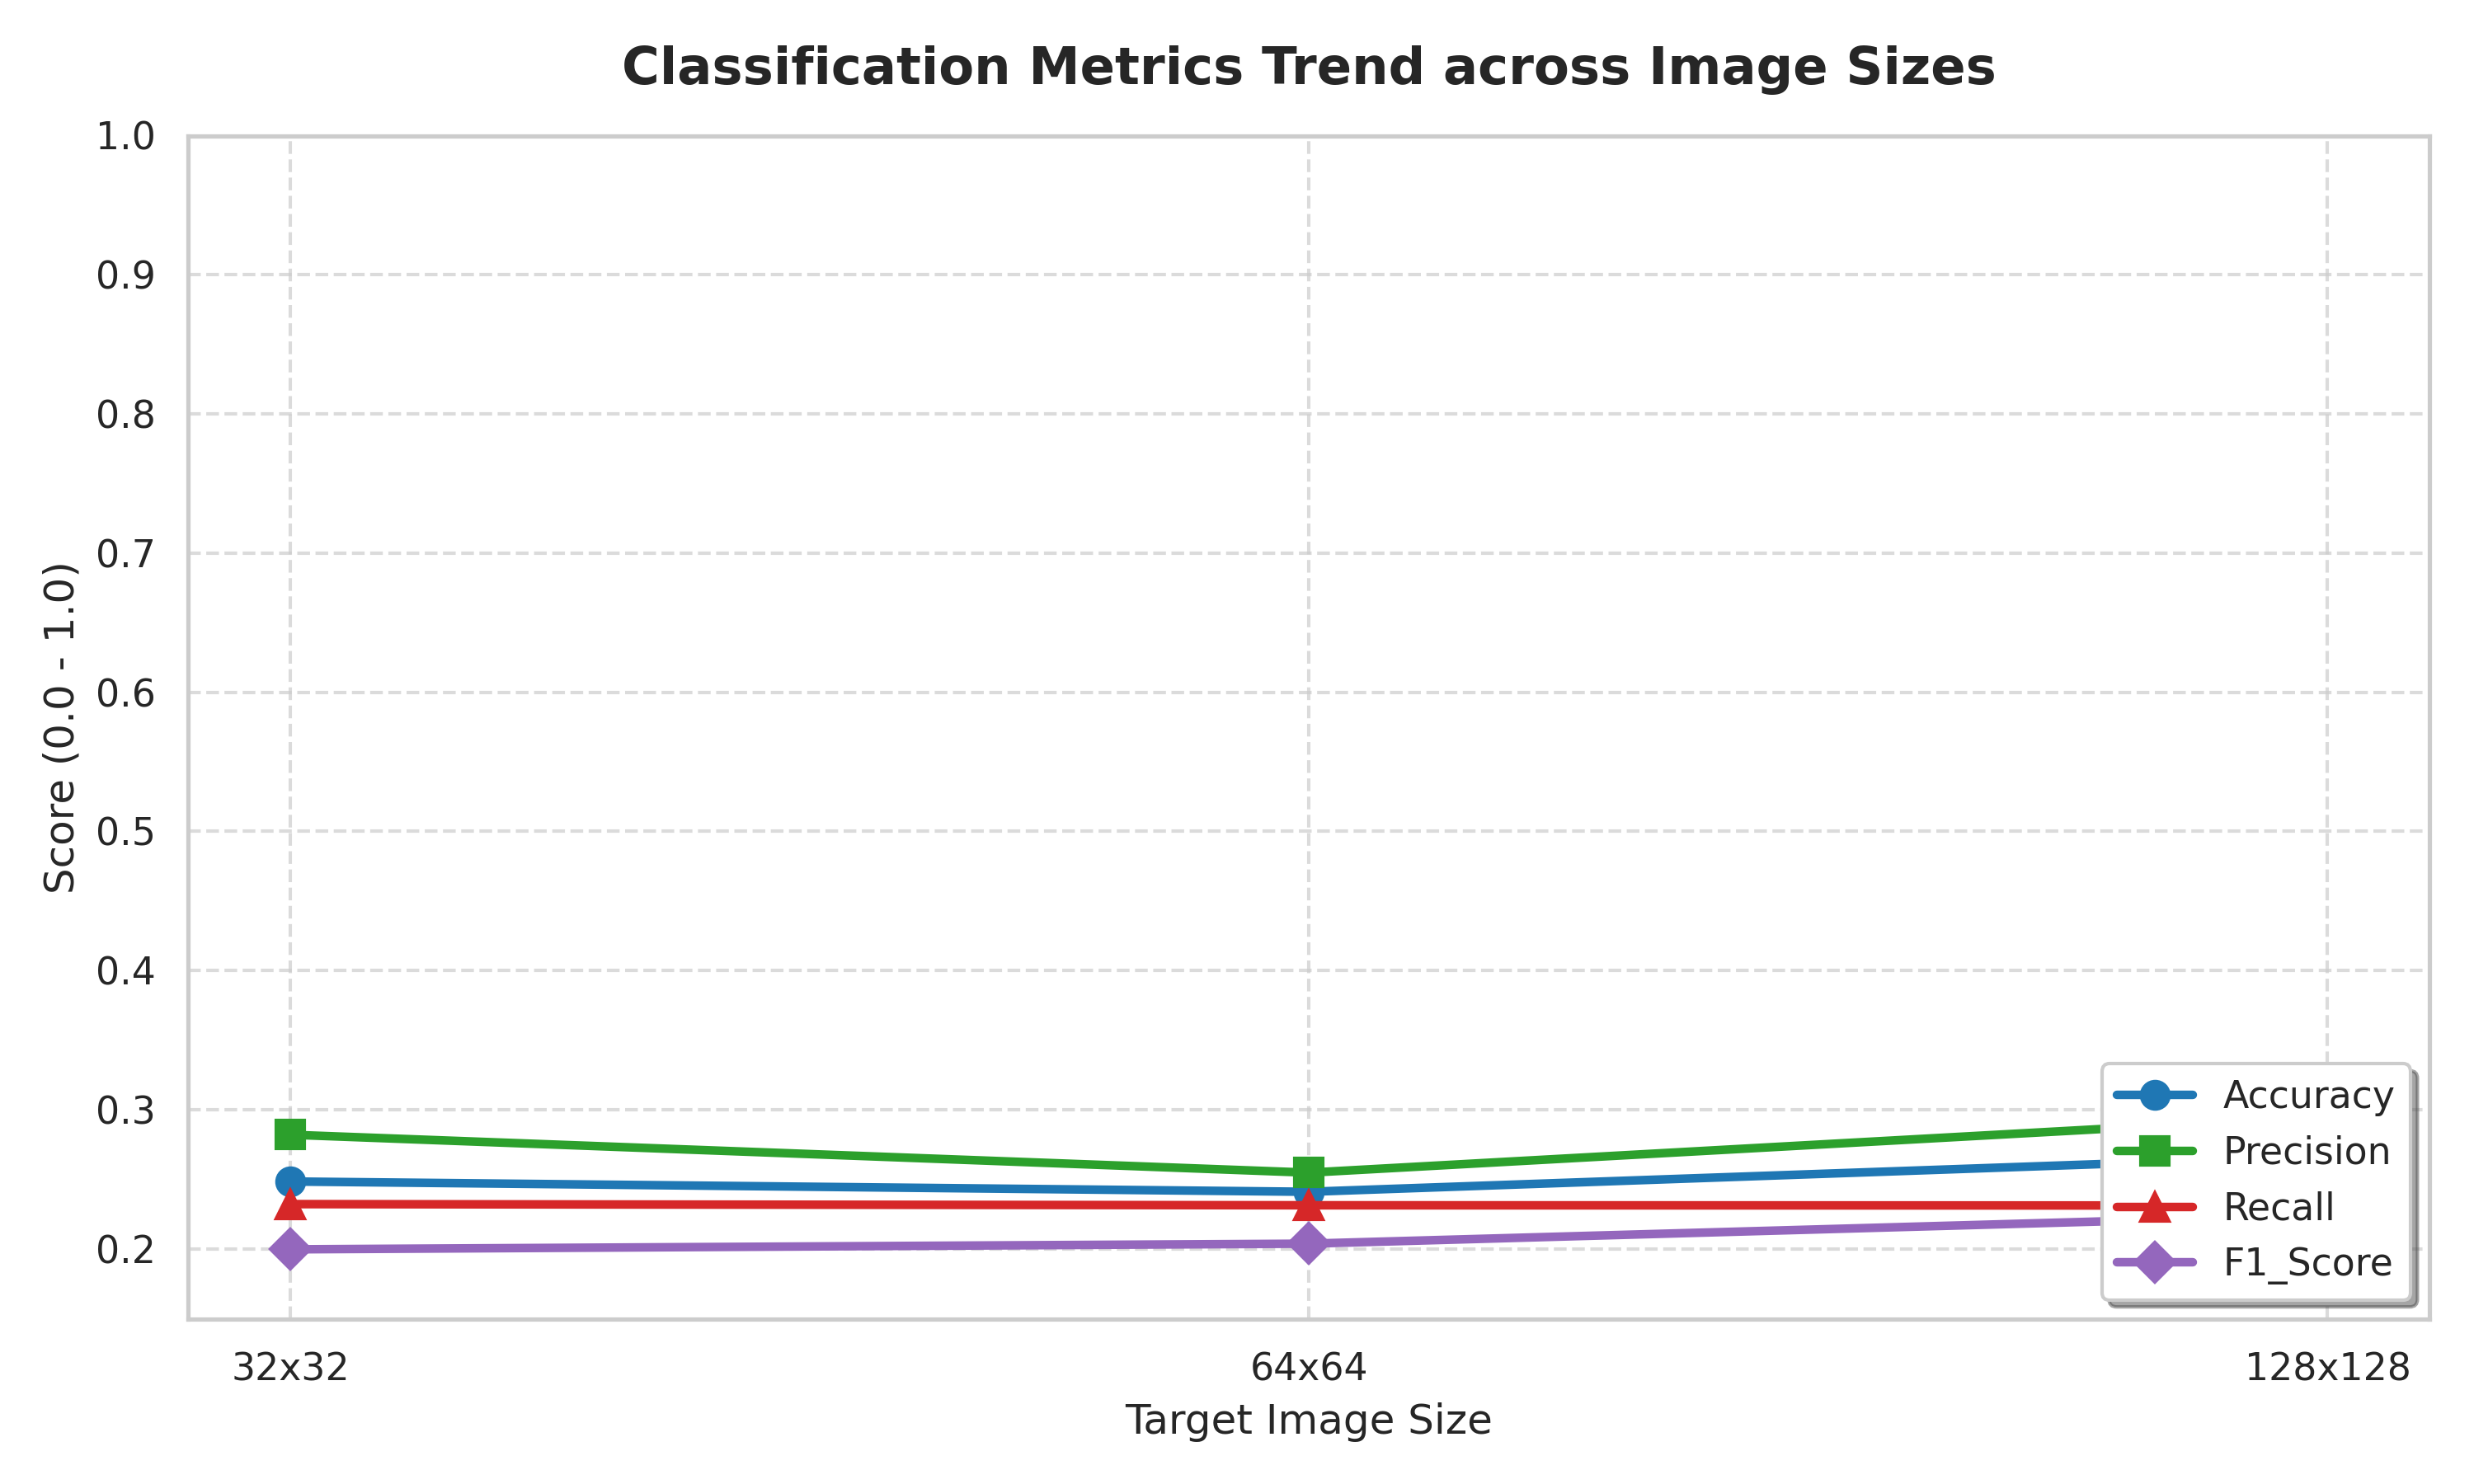


BIỂU ĐỒ 2: ĐỐI CHIẾU CHẤT LƯỢNG (SSIM) VÀ HIỆU SUẤT (F1)


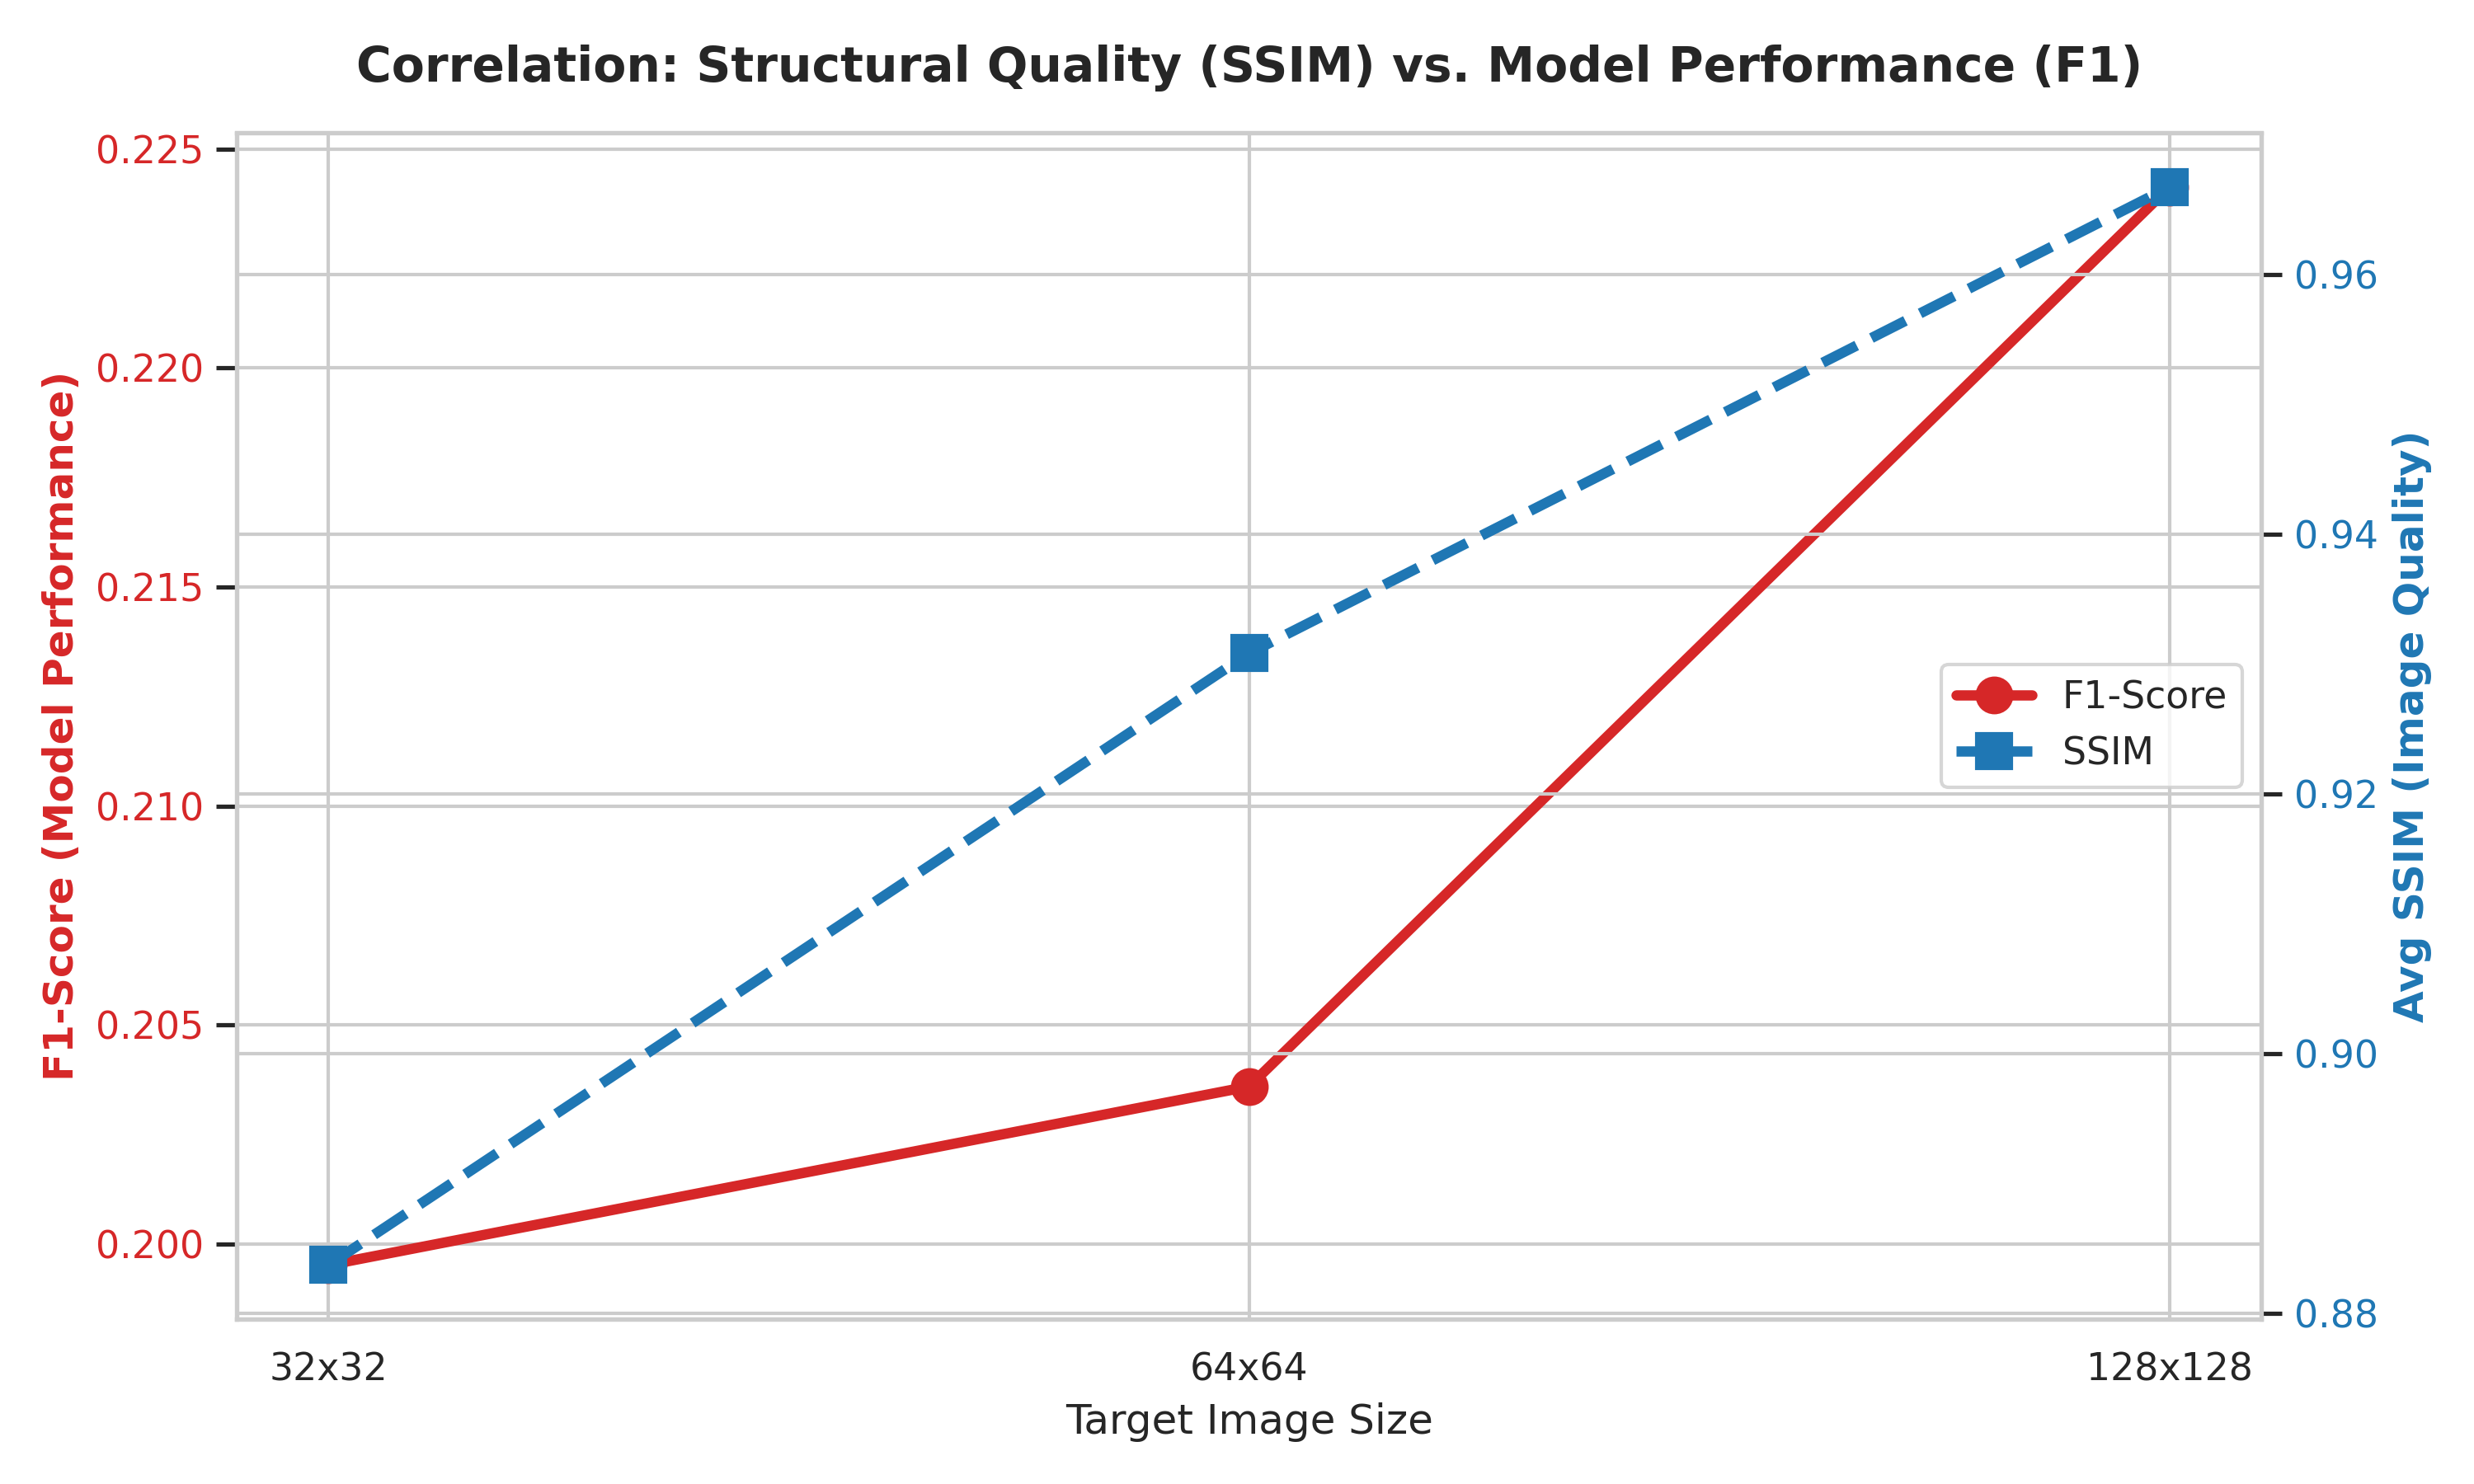

In [11]:
# Đường dẫn lưu file ảnh
trend_img = "ml_metrics_trend.png"
corr_img = "quality_vs_performance.png"

# Vẽ xu hướng các độ đo phân loại
plot_classification_metrics_trend(final_ablation_df, save_path=trend_img)

# Vẽ đối chiếu Chất lượng và Hiệu suất
plot_quality_vs_performance(final_ablation_df, save_path=corr_img)

print("\nBIỂU ĐỒ 1: XU HƯỚNG CÁC ĐỘ ĐO PHÂN LOẠI")
display(Image(filename=trend_img))

print("\nBIỂU ĐỒ 2: ĐỐI CHIẾU CHẤT LƯỢNG (SSIM) VÀ HIỆU SUẤT (F1)")
display(Image(filename=corr_img))

<a id="sec-4-3"></a>

## 4.3. Phân tích

<a id="sec-4-3-1"></a>

### 4.3.1. Phân tích Xu hướng biến thiên của các Độ đo
* Dựa trên bảng số liệu tổng hợp, ta quan sát thấy các xu hướng thay đổi rõ rệt như sau:
  - **Độ đo giảm mạnh:**
    + **PSNR (27.45 dB $\rightarrow$ 21.50 dB):** Giảm liên tục khi kích thước thu nhỏ. Điều này minh chứng cho việc nhiễu tín hiệu tăng cao khi thuật toán nội suy phải nén dữ liệu vào một không gian pixel hạn chế.
    + **SSIM (0.967 $\rightarrow$ 0.884):** Giảm đáng kể, cho thấy cấu trúc chi tiết của vật thể bị phá hủy dần.
    + **Training Time (1041s $\rightarrow$ 94s):** Đây là độ đo giảm mạnh nhất (giảm hơn 11 lần).
  - **Độ đo biến động nhẹ hoặc đi ngang:**
    + **Accuracy và F1-Score:** Có xu hướng giảm nhưng không quá dốc ($26\% \rightarrow 24\%$).
    + **Recall (0.231 $\rightarrow$ 0.232):** Đây là độ đo **ổn định** nhất, gần như không thay đổi bất chấp việc kích thước ảnh bị cắt giảm 16 lần về mặt diện tích ($128^2$ so với $32^2$).

<a id="sec-4-3-2"></a>

### 4.3.2. Giải thích sự thay đổi
* Có thể thấy, sự thay đổi mạnh mẽ nhất nằm ở Training Time và Chỉ số Chất lượng cấu trúc (SSIM). Chúng ta có thể lý giải như sau:
  - **Về mặt Ngữ nghĩa và Pixel (Liên hệ giữa SSIM và ML Metrics):** Khi chúng ta thực hiện resize bằng phương pháp nội suy điểm ảnh (`INTER_AREA`), các chi tiết tần số cao (viền, lông thú, mắt đối tượng) sẽ bị làm mờ để tránh hiện tượng aliasing. Tuy nhiên, thuật toán **Logistic Regression (SGD)** mà chúng ta sử dụng là một mô hình tuyến tính làm việc trên vector phẳng (raw pixels). Mô hình này chủ yếu học các đặc trưng toàn cục (mảng màu, hình khối lớn) hơn là các chi tiết vi mô.
    + Do **SSIM** ở mốc $32 \times 32$ vẫn duy trì ở mức **0.88** (mức khá tốt), các cấu trúc của con vật vẫn được bảo toàn.
    + Vì các đặc trưng cấu trúc lớn không bị mất đi hoàn toàn, nên độ đo **Recall** vẫn được giữ vững. Điều này giải thích tại sao dù ảnh mờ hơn (PSNR thấp), mô hình vẫn giữ được khả năng nhận diện các đặc trưng cốt lõi để phân loại giữa các lớp.
  - **Sự đánh đổi Tài nguyên và Hiệu suất:** Việc kích thước ảnh giảm làm giảm số chiều của không gian đặc trưng ($49152$ chiều ở size 128 xuống còn $3072$ chiều ở size 32). Sự sụt giảm khổng lồ về chiều dữ liệu giúp mô hình hội tụ cực nhanh (tiết kiệm 90% thời gian), trong khi F1-Score chỉ bị hy sinh khoảng 2.4%.

<a id="sec-4-3-3"></a>

### 4.3.3. Lựa chọn Kích thước tối ưu
* Dựa trên các phân tích định lượng, kích thước $64 \times 64$ được chọn là kích thước tối ưu cho giai đoạn tiền xử lý của dự án này.
* **Lý do lựa chọn dựa trên sự kết hợp các độ đo như sau:**
  - **Sự cân bằng giữa Chất lượng và Hiệu suất (F1 với SSIM):** Tại mốc $64 \times 64$, chỉ số SSIM vẫn giữ được mức rất cao (**0.93**), đảm bảo cấu trúc hình ảnh không bị biến dạng quá nhiều cho các bước xử lý nâng cao sau này. Trong khi đó, hiệu suất F1-Score ở mốc này ($20.3\%$) không chênh lệch quá lớn so với mốc 128x128.
  - **Tối ưu hóa tài nguyên:** Kích thước $64 \times 64$ giúp giảm thời gian huấn luyện từ **1041 giây xuống còn 314 giây** (nhanh hơn gấp 3 lần so với 128x128). Đây là một sự đánh đổi cực kỳ hiệu quả về mặt kinh tế
  - **Ngưỡng an toàn của Recall:** Quan sát biểu đồ xu hướng, chúng ta thấy **Recall** bắt đầu có sự biến động nhẹ khi xuống tới mốc 32x32. Để đảm bảo mô hình không bỏ sót các đặc trưng quan trọng của các lớp khó (như Spider hay Butterfly), mốc $64 \times 64$ đóng vai trò là một sự lựa chọn an toàn, giữ cho thông tin ngữ nghĩa đủ phong phú nhưng vẫn nhẹ nhàng cho hệ thống tính toán.
* **Kết luận:** Kích thước $64 \times 64$ là sự lựa chọn dung hoà ở cả 2 khía cạnh là thời gian và sự hiệu quả, đảm bảo giữ được 93% cấu trúc ảnh và 90% hiệu suất phân loại của mô hình gốc, trong khi chỉ tiêu tốn 30% thời gian tính toán.